In [122]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lu_factor, lu_solve
import sympy as sp
from scipy.integrate import solve_bvp, trapezoid, cumulative_trapezoid

In [123]:
#given parameters
nu_inf = 1.5e-6 #freestream kinematic viscosity (m2/s)
u_inf = 30 #freestream vel (m/s)
L = 1 #(m)
delta = 0.005 #initial boundary layer thickness (m)
Ny = 250 #updated for project 3
y_max = 50*delta #updated for project 3
s = 10 #stretch factor

#estimate x0 for turbulent boundary layer:
x0 = (delta/0.375)**1.25*(u_inf/nu_inf)**0.25 

x_tot = 40*L #independent var length
dx = 0.01 #x step size
Nx = int(x_tot/dx) #x partitions

#stretched y grid
eta = np.linspace(0, 1, Ny)
d_eta = eta[1] - eta[0]
y = y_max*(np.sinh(s*eta)/np.sinh(s))

#stretched y grid derivatives
deta_dy = np.sinh(s)/(s*y_max*np.cosh(s*eta))
d2eta_dy2 = -(np.sinh(s)**2*np.sinh(s*eta))/(s*y_max**2*np.cosh(s*eta)**3)

#turbulence parameters
kappa = 0.41
ya_plus = 9.7
c1 = 0.001

print(x0)

0.3029918310579998


In [124]:
# central diff, 4th order for interior points, 2nd order for boundary-adjacent points
du_deta = np.zeros((Ny, Ny))
d2u_deta2 = np.zeros((Ny, Ny))

for i in range(1, Ny - 1):
    if i == 1 or i == Ny - 2:
        #2nd order cd, for boundary-adjacent points
        du_deta[i, i-1] = -1/(2*d_eta) 
        du_deta[i, i+1] = 1/(2*d_eta)
        
        d2u_deta2[i, i-1] = 1/d_eta**2
        d2u_deta2[i, i] = -2/d_eta**2
        d2u_deta2[i, i+1] = 1/d_eta**2
    else:
        #4th order cd, for interior points
        du_deta[i, i-2] = 1/(12*d_eta)
        du_deta[i, i-1] = -8/(12*d_eta)
        du_deta[i, i+1] = 8/(12*d_eta)
        du_deta[i, i+2] = -1/(12*d_eta)
        
        d2u_deta2[i, i-2] = -1/(12*d_eta**2)
        d2u_deta2[i, i-1] = 16/(12*d_eta**2)
        d2u_deta2[i, i] = -30/(12*d_eta**2)
        d2u_deta2[i, i+1] = 16/(12*d_eta**2)
        d2u_deta2[i, i+2] = -1/(12*d_eta**2)

In [ ]:
u = np.zeros(Ny) # init u
v = np.zeros(Ny) # init v

#at the initial location, assume the laminar velocity profile
for i in range(Ny):
    if y[i]/delta <= 1:
        u[i] = u_inf*(y[i]/delta*(3/2-1/2*((y[i]/delta)**2))) 
    else:
        u[i] = u_inf

x_vals = [0,470, 970, 1470, 3970] # x steps -> x= x0 + n*dx
u_store_numer = {0: np.copy(u)} # stored in dictionary per your setup
v_store_numer = {0: np.copy(v)} 

#storre
x_array = np.zeros(Nx + 1)
delta_store = np.zeros(Nx + 1)
cf_store = np.zeros(Nx + 1)

x_array[0] = x0
delta_store[0] = delta

for n in range(1, Nx + 1): 
    x_now = x0 + n*dx
    x_array[n] = x_now
    
    #friction vel
    #2nd order fwd diff at the wall
    du_deta_wall = (-3*u[0]+4*u[1]-u[2])/(2*d_eta)
    du_dy_wall = du_deta_wall*deta_dy[0]
    tau_w = nu_inf*np.abs(du_dy_wall)
    u_star = np.sqrt(tau_w)
    
    #boundary layer thickness calc
    idx_delta = np.argmax(u >= 0.994 * u_inf)
    delta_x = y[idx_delta] if idx_delta > 0 else delta
    
    delta_store[n] = delta_x
    cf_store[n] = tau_w/(0.5*u_inf**2)
    
    #eddy viscosity (nu_t) and derivative
    nu_t = np.zeros(Ny)
    dnut_dy = np.zeros(Ny)
    nut_max = c1 * u_inf * delta_x
    
    for i in range(Ny):
        y_plus = y[i] * u_star/nu_inf
        term = np.clip(y_plus/ya_plus, 0, 100) # prevent overflow in cosh
        
        #reichardt 
        nut_inner = kappa*nu_inf *(y_plus - ya_plus*np.tanh(term))
        dnut_dy_inner = kappa*u_star*(1.0 -(1.0 / np.cosh(term))**2)
        
        #clauser model for when calculated v_t from reichardt > (v_t)_max
        if nut_inner < nut_max:
            nu_t[i] = nut_inner
            dnut_dy[i] = dnut_dy_inner
        else:
            nu_t[i] = nut_max
            dnut_dy[i] = 0.0

    #diffusion convection terms (now adding turbulent effect)
    diff_conv = np.zeros((Ny, Ny))
    for i in range(1, Ny - 1):
        nu_eff = nu_inf + nu_t[i] #effective viscosity including turbulence
        v_eff = v[i] - dnut_dy[i] #effective convection velocity including turbulence viscosity gradient
        
        j = nu_eff*deta_dy[i]**2 
        k = nu_eff*d2eta_dy2[i] - v_eff*deta_dy[i]  

        diff_conv[i, :] = (j*d2u_deta2[i, :] + k*du_deta[i, :]) #rearranged PDE, du/dx = ... (see eq. 7 in report)
        
    #Au=b
    A = np.diag(u) - diff_conv*dx/2 #C-N: step n+1 
    b = (np.diag(u) + diff_conv*dx/2)@u #C-N: u*du/dx at step n 

    b[0] = 0 # u=0 at wall
    b[-1] = u_inf # u=u_inf at freestream

    #top boundary
    A[-1, :] = 0 
    A[-1, -1] = 1 
    #bottom boundary
    A[0, :] = 0 
    A[0, 0] = 1     
    
    u_new = lu_solve((lu_factor(A)), b)  #lu solve for u

    #update v using continuity eq, du/dx + dv/dy = 0
    du_dx = (u_new - u)/dx
    v_new = cumulative_trapezoid(-du_dx, x=y, initial=0)

    u = u_new
    v = v_new

    u_store_numer[n]=u
    v_store_numer[n]=v

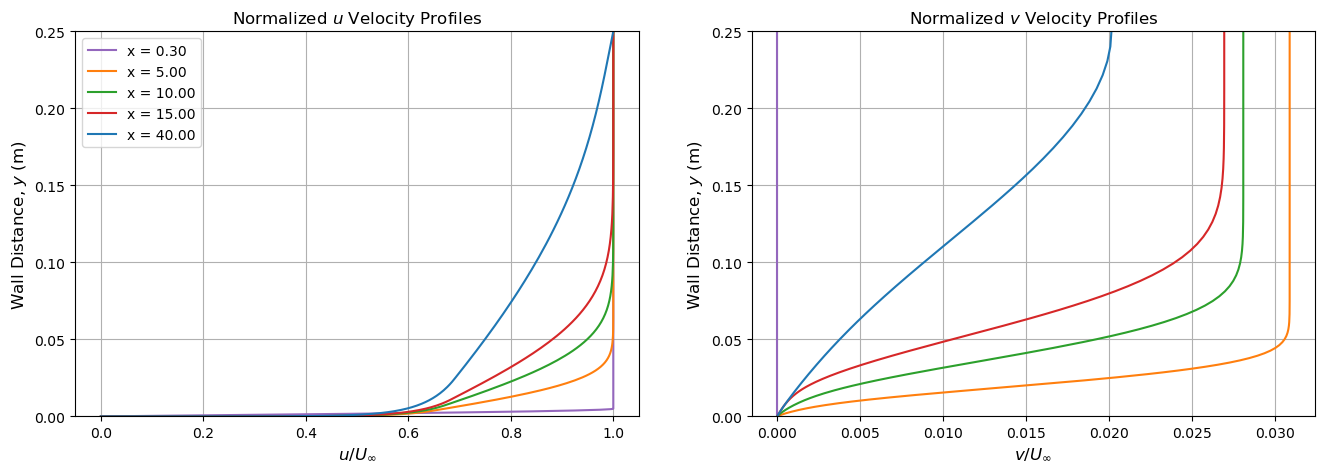

In [ ]:
#velocity plots
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
colors = ['tab:purple','tab:orange','tab:green','tab:red','tab:blue']

#velocity plot
for idx, n in enumerate(x_vals):
    x_now = x_array[n]
    axs[0].plot(u_store_numer[n]/u_inf, y, '-', color=colors[idx], label=f'x = {x_now:.2f}')
axs[0].set_title('Normalized $u$ Velocity Profiles', fontsize=12)
axs[0].set_xlabel('$u / U_{\\infty}$', fontsize=12)
axs[0].set_ylabel('Wall Distance, $y$ (m)', fontsize=12)
#axs[0].set_ylim(0, 0.01)
axs[0].set_ylim(0, 0.25)
axs[0].legend()
axs[0].grid()

for idx, n in enumerate(x_vals):
    x_now = x_array[n]
    axs[1].plot(v_store_numer[n], y, '-', color=colors[idx], label=f'x = {x_now:.2f}')
axs[1].set_title('Normalized $v$ Velocity Profiles', fontsize=12)
axs[1].set_xlabel('$v / U_{\\infty}$', fontsize=12)
axs[1].set_ylabel('Wall Distance, $y$ (m)', fontsize=12)
axs[1].set_ylim(0, 0.25)
axs[1].grid()

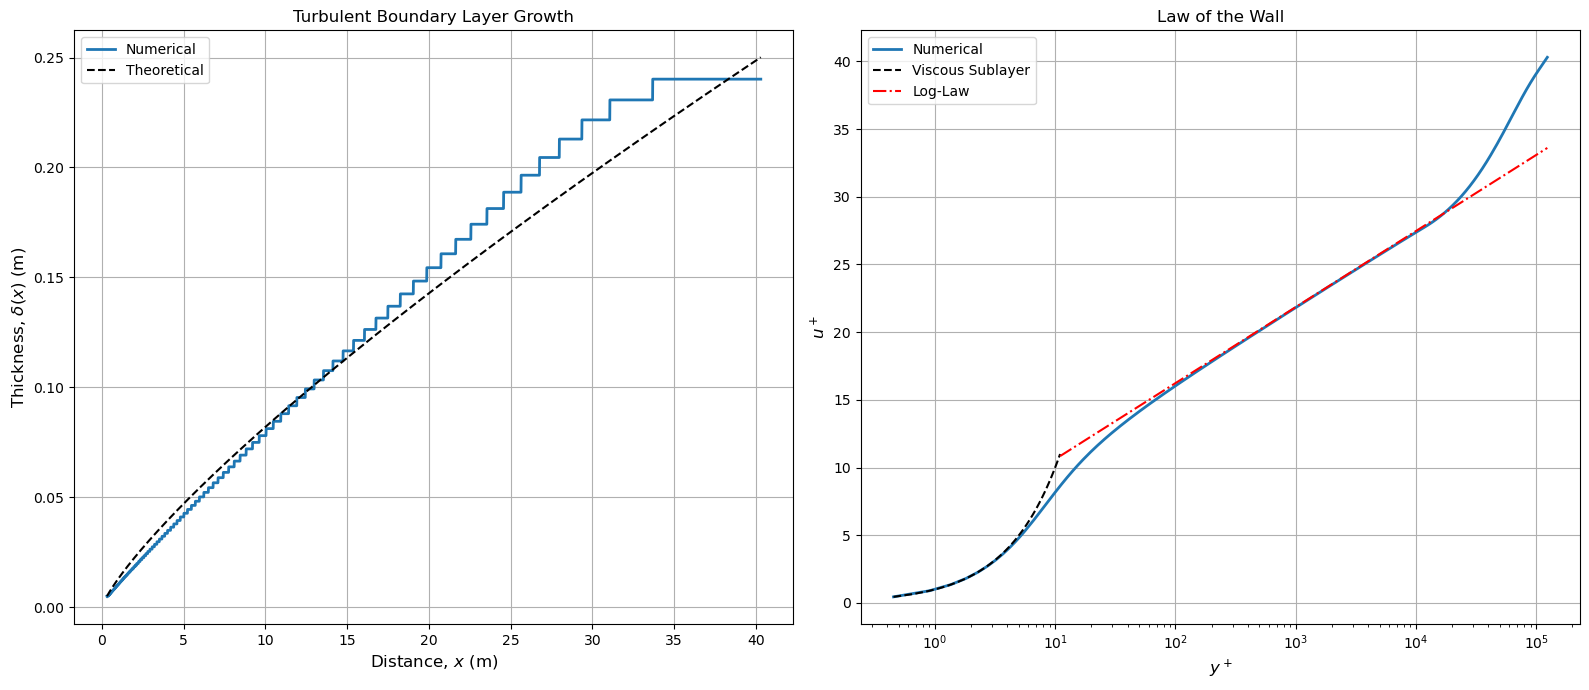

In [ ]:
#boundary layer thickness and law of wall check
fig, axs = plt.subplots(1, 2, figsize=(16, 7))
#boundary layer thickness
Re_x = (u_inf*x_array)/nu_inf
delta_theory = 0.375*x_array*(Re_x)**(-1/5)
axs[0].plot(x_array, delta_store, linewidth=2, label='Numerical')
axs[0].plot(x_array, delta_theory, '--', color='k', label='Theoretical')
axs[0].set_title('Turbulent Boundary Layer Growth', fontsize=12)
axs[0].set_xlabel('Distance, $x$ (m)', fontsize=12)
axs[0].set_ylabel('Thickness, $\\delta(x)$ (m)', fontsize=12)
axs[0].legend()
axs[0].grid()

#law of the wall
n_final = x_vals[-1]
u_final = u_store_numer[n_final]

#recalc u* for the final step
du_deta_wall = (-3*u_final[0] + 4*u_final[1] -u_final[2])/(2*d_eta) 
du_dy_wall = du_deta_wall*deta_dy[0]
u_star_final = np.sqrt(nu_inf * np.abs(du_dy_wall))

#dimensionless quantities (exclude y=0 to avoid log(0))
y_plus_final = y[1:]*u_star_final / nu_inf  
u_plus_final = u_final[1:] / u_star_final
axs[1].semilogx(y_plus_final, u_plus_final, linewidth=2, label='Numerical')

#y_plus_k31 = np.copy(y_plus_final) #for sensitivity
#u_plus_k31 = np.copy(u_plus_final)

#y_plus_k51 = np.copy(y_plus_final)  #for sensitivity
#u_plus_k51 = np.copy(u_plus_final)

# Stash low c1 variation
#delta_c1_low = np.copy(delta_store) #for sensitivity

# Stash high c1 variation
#delta_c1_high = np.copy(delta_store)  #for sensitivity

#theoretical Regions
y_visc = np.linspace(min(y_plus_final), 11, 50)
axs[1].semilogx(y_visc, y_visc, '--', color='k', label='Viscous Sublayer')
y_log = np.linspace(11, max(y_plus_final), 100)
u_log = (1/kappa) * np.log(y_log) + 5.0

axs[1].semilogx(y_log, u_log, '-.', color='r', label='Log-Law')
axs[1].set_title('Law of the Wall', fontsize=12)
axs[1].set_xlabel('$y^+$', fontsize=12)
axs[1].set_ylabel('$u^+$', fontsize=12)
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()

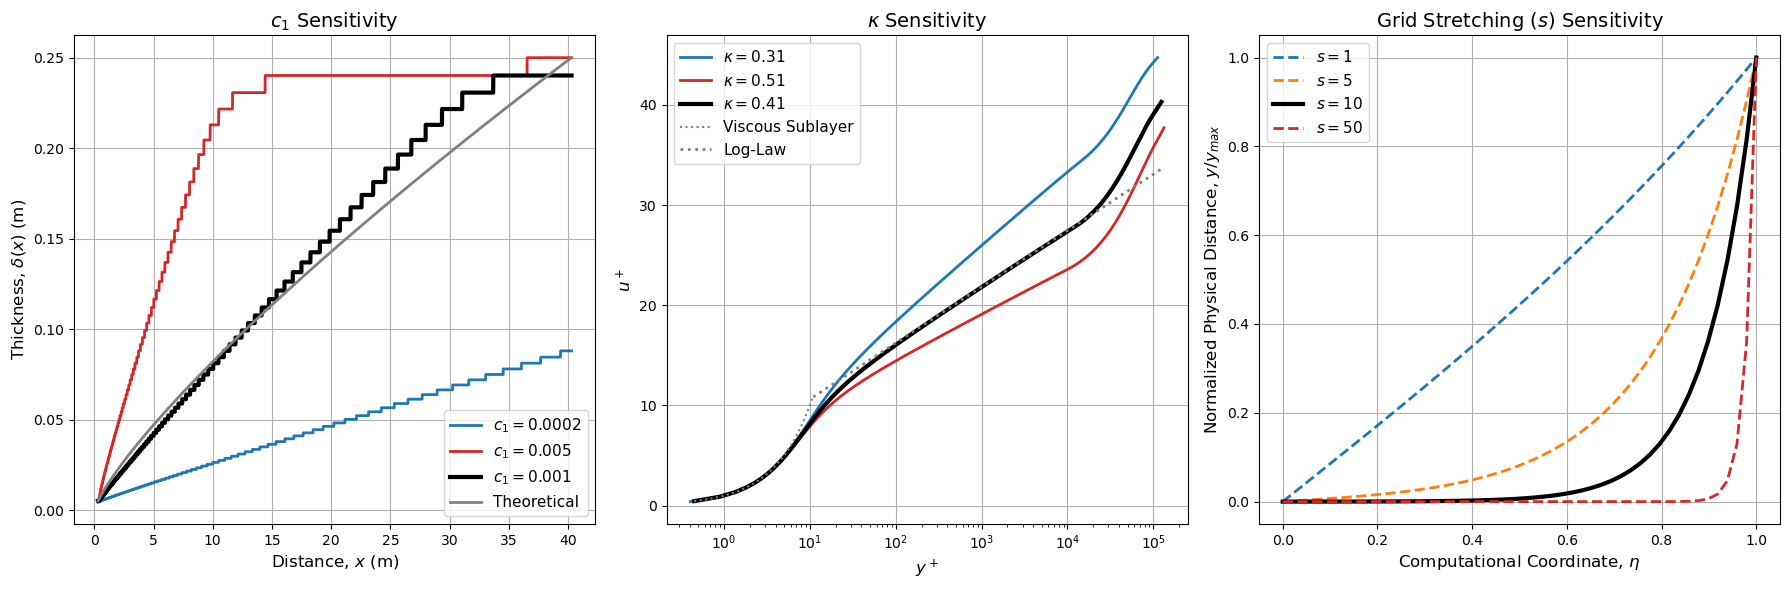

In [128]:
#SENSITIVITY ANAYLSIS PLOTS
#IMPORTANT, MUST RUN ABOVE CELLS FIRST TO POPULATE THE VARIATIONS IN THE STORED ARRAYS
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

#c1 sensitivity
Re_x = (u_inf * x_array)/nu_inf
delta_theory = 0.375*x_array*(Re_x)**(-1/5)

#c1 sensitivity
axs[0].plot(x_array, delta_c1_low, '-', color='tab:blue', linewidth=2, label='$c_1 = 0.0002$')
axs[0].plot(x_array, delta_c1_high, '-', color='tab:red', linewidth=2, label='$c_1 = 0.005$')

#default
axs[0].plot(x_array, delta_store, '-', color='black', linewidth=3, label='$c_1 = 0.001$')
axs[0].plot(x_array, delta_theory, '-', color='gray', linewidth=2, label='Theoretical')

axs[0].set_title('$c_1$ Sensitivity', fontsize=14)
axs[0].set_xlabel('Distance, $x$ (m)', fontsize=12)
axs[0].set_ylabel('Thickness, $\\delta(x)$ (m)', fontsize=12)
axs[0].legend(fontsize=11)
axs[0].grid(True)

#kappa sensitivity
axs[1].semilogx(y_plus_k31, u_plus_k31, '-', color='tab:blue', linewidth=2, label='$\\kappa = 0.31$')
axs[1].semilogx(y_plus_k51, u_plus_k51, '-', color='tab:red', linewidth=2, label='$\\kappa = 0.51$')

#default
axs[1].semilogx(y_plus_final, u_plus_final, '-', color='black', linewidth=3, label='$\\kappa = 0.41$')

#theory
y_visc = np.linspace(min(y_plus_final), 11, 50)
axs[1].semilogx(y_visc, y_visc, ':', color='tab:gray', label='Viscous Sublayer')

y_log = np.linspace(11, max(y_plus_final), 100)
u_log = (1/0.41) * np.log(y_log) + 5.0 
axs[1].semilogx(y_log, u_log, ':', color='tab:gray', linewidth=2, label='Log-Law')

axs[1].set_title('$\\kappa$ Sensitivity', fontsize=14)
axs[1].set_xlabel('$y^+$', fontsize=12)
axs[1].set_ylabel('$u^+$', fontsize=12)
axs[1].legend(fontsize=11)
axs[1].grid(True)

#s sensitivity
eta = np.linspace(0, 1, 50) 
s_test_vals = [1, 5, 10, 50]
colors_s = ['tab:blue', 'tab:orange', 'black', 'tab:red']

for idx, s_test in enumerate(s_test_vals):
    y_test = np.sinh(s_test * eta) / np.sinh(s_test)
    
    # Match baseline formatting (s=10)
    linewidth = 3 if s_test == 10 else 2
    linestyle = '-' if s_test == 10 else '--'
    label_str = f'$s = {s_test}$' if s_test == 10 else f'$s = {s_test}$'
    
    axs[2].plot(eta, y_test, linestyle=linestyle, linewidth=linewidth, color=colors_s[idx], label=label_str)

axs[2].set_title('Grid Stretching ($s$) Sensitivity', fontsize=14)
axs[2].set_xlabel('Computational Coordinate, $\\eta$', fontsize=12)
axs[2].set_ylabel('Normalized Physical Distance, $y/y_{max}$', fontsize=12)
axs[2].legend(fontsize=11)
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
colors = ['tab:purple','tab:orange','tab:green','tab:red','tab:blue']

#velocity plot
for idx, n in enumerate(x_vals):
    x_now = x_array[n]
    axs[0].plot(u_store_numer[n]/u_inf, y/delta_store[n], '-', color=colors[idx], label=f'x = {x_now:.2f}')
axs[0].set_title('Normalized $u$ Velocity Profiles', fontsize=12)
axs[0].set_xlabel('$u / U_{\\infty}$', fontsize=12)
axs[0].set_ylabel('$y/\\delta$', fontsize=12)
axs[0].set_ylim(0,1)
axs[0].legend()
axs[0].grid()

for idx, n in enumerate(x_vals):
    x_now = x_array[n]
    axs[1].plot(v_store_numer[n], y/delta_store[n], '-', color=colors[idx], label=f'x = {x_now:.2f}')
axs[1].set_title('Normalized $v$ Velocity Profiles', fontsize=12)
axs[1].set_xlabel('$v / U_{\\infty}$', fontsize=12)
axs[1].set_ylabel('$y/\\delta$', fontsize=12)
axs[1].set_ylim(0,1)
axs[1].set_xlim(0, 0.03)
axs[1].grid()